# 1kW LCCLS Efficiency Analysis

`1kW_LCCLS_sim.txt`를 읽어서 마지막 정상상태 구간의 평균 전력과 효율을 계산합니다.

- 기본값은 현재 export된 컬럼명을 기준으로 입력/출력 전력을 자동 추정합니다.
- 추정이 맞지 않으면 아래 설정 셀에서 `INPUT_COLUMN`, `OUTPUT_COLUMN`만 직접 지정하면 됩니다.


In [8]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.6g}')

In [9]:
# User settings
DATA_PATH = Path('1kW_LCCLS_sim.txt')
FSW_HZ = 6.78e6
WINDOW_CYCLES = 200

# 자동 추정이 애매하면 컬럼명을 문자열로 직접 지정하세요.
INPUT_COLUMN = None
OUTPUT_COLUMN = None


In [10]:
df = pd.read_csv(DATA_PATH, sep='\t')
df.columns = [c.strip() for c in df.columns]

if 'time' not in df.columns:
    raise ValueError(f"'time' column not found: {df.columns.tolist()}")

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='raise')

print(f'rows: {len(df):,}')
print('columns:')
for col in df.columns:
    print(f'  - {col}')

df.head()

rows: 536,367
columns:
  - time
  - V(N019,N021)*(-I(C3))
  - V(sw1,sw2)*(-I(C2))


,time,"V(N019,N021)*(-I(C3))","V(sw1,sw2)*(-I(C2))"
0,0,-0,-0
1,7.20179e-12,0,-0
2,1.44036e-11,0,-0
3,2.88072e-11,0,-0
4,5.76143e-11,-0,0


In [11]:
power_columns = [c for c in df.columns if c != 'time']

def pick_column(candidates, fallback_index):
    lowered = {c.lower(): c for c in power_columns}
    for pattern in candidates:
        for key, original in lowered.items():
            if pattern in key:
                return original
    return power_columns[fallback_index]

input_col = INPUT_COLUMN or pick_column(['pin', 'input', 'vdc', 'sw1,sw2', 'c2'], 1 if len(power_columns) > 1 else 0)
output_col = OUTPUT_COLUMN or pick_column(['pout', 'output', 'load', 'rl', 'n019,n021', 'c3'], 0)

if input_col == output_col and len(power_columns) > 1:
    remaining = [c for c in power_columns if c != input_col]
    output_col = remaining[0]

print(f'input power column : {input_col}')
print(f'output power column: {output_col}')

input power column : V(sw1,sw2)*(-I(C2))
output power column: V(N019,N021)*(-I(C3))


In [12]:
window_time = WINDOW_CYCLES / FSW_HZ
t_end = df['time'].max()
t_start = max(df['time'].min(), t_end - window_time)
steady = df[df['time'] >= t_start].copy()

def avg_trapz(time_s, value):
    dt = np.trapezoid(np.ones_like(value), x=time_s)
    return np.trapezoid(value, x=time_s) / dt

pin_avg = avg_trapz(steady['time'].to_numpy(), steady[input_col].to_numpy())
pout_avg = avg_trapz(steady['time'].to_numpy(), steady[output_col].to_numpy())

eff_signed = np.nan if np.isclose(pin_avg, 0.0) else 100.0 * pout_avg / pin_avg
eff_abs = np.nan if np.isclose(pin_avg, 0.0) else 100.0 * abs(pout_avg) / abs(pin_avg)

summary = pd.Series({
    'window_start_s': t_start,
    'window_end_s': t_end,
    'window_cycles': WINDOW_CYCLES,
    'pin_avg_W': pin_avg,
    'pout_avg_W': pout_avg,
    'eff_signed_pct': eff_signed,
    'eff_abs_pct': eff_abs,
})

summary

window_start_s   4.42478e-05
window_end_s     7.37463e-05
window_cycles            200
pin_avg_W           1,878.41
pout_avg_W          1,750.81
eff_signed_pct       93.2069
eff_abs_pct          93.2069
dtype: float64

부호 기준이 export 식에 따라 달라질 수 있어서 `eff_signed_pct`와 `eff_abs_pct`를 같이 표시합니다.
일반적으로 전력 방향만 반대로 잡혔다면 `eff_abs_pct`를 보면 됩니다.


C:\Users\harry\AppData\Local\Temp\ipykernel_4632\1993851307.py:13: RuntimeWarning: divide by zero encountered in divide
  inst_eff = np.where(np.abs(df[input_col].to_numpy()) > 1e-12, 100.0 * df[output_col].to_numpy() / df[input_col].to_numpy(), np.nan)
C:\Users\harry\AppData\Local\Temp\ipykernel_4632\1993851307.py:13: RuntimeWarning: invalid value encountered in divide
  inst_eff = np.where(np.abs(df[input_col].to_numpy()) > 1e-12, 100.0 * df[output_col].to_numpy() / df[input_col].to_numpy(), np.nan)


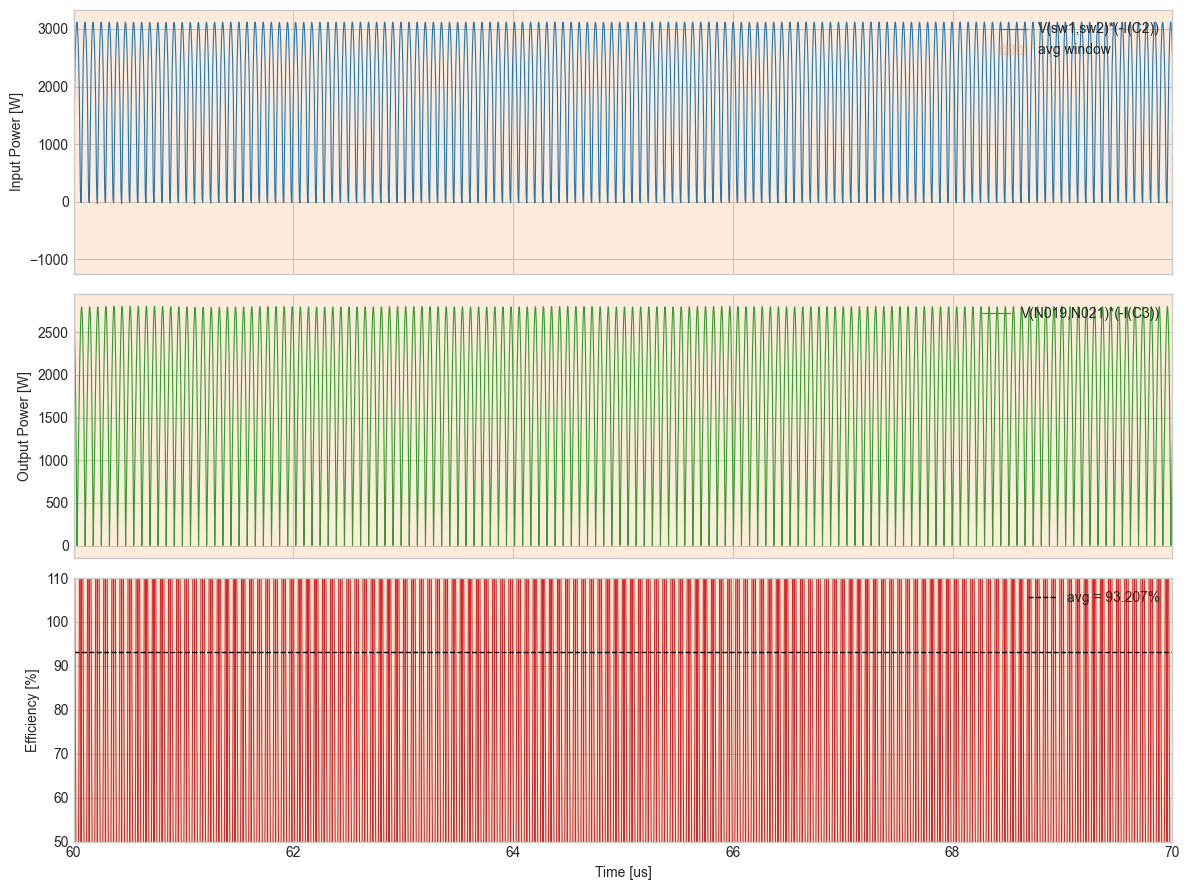

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(df['time'] * 1e6, df[input_col], lw=0.8, label=input_col)
axes[0].axvspan(t_start * 1e6, t_end * 1e6, color='tab:orange', alpha=0.15, label='avg window')
axes[0].set_ylabel('Input Power [W]')
axes[0].legend(loc='upper right')

axes[1].plot(df['time'] * 1e6, df[output_col], lw=0.8, color='tab:green', label=output_col)
axes[1].axvspan(t_start * 1e6, t_end * 1e6, color='tab:orange', alpha=0.15)
axes[1].set_ylabel('Output Power [W]')
axes[1].legend(loc='upper right')

inst_eff = np.where(np.abs(df[input_col].to_numpy()) > 1e-12, 100.0 * df[output_col].to_numpy() / df[input_col].to_numpy(), np.nan)
axes[2].plot(df['time'] * 1e6, inst_eff, lw=0.8, color='tab:red')
axes[2].axhline(eff_signed, color='black', ls='--', lw=1.0, label=f'avg = {eff_signed:.3f}%')
axes[2].axvspan(t_start * 1e6, t_end * 1e6, color='tab:orange', alpha=0.15)
axes[2].set_ylabel('Efficiency [%]')
axes[2].set_ylim(50, 110)
axes[2].set_xlim(60, 70)
axes[2].set_xlabel('Time [us]')
axes[2].legend(loc='upper right')

plt.tight_layout()

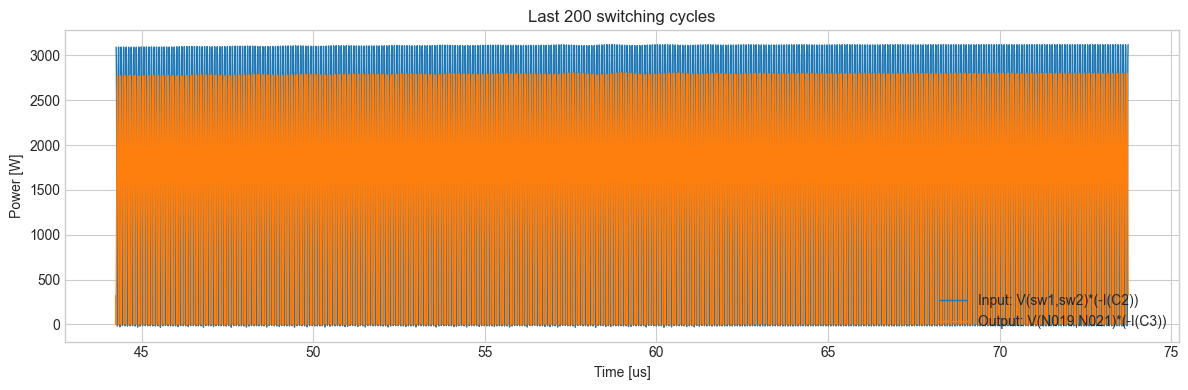

In [14]:
# 마지막 구간만 확대해서 확인
zoom = steady.copy()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(zoom['time'] * 1e6, zoom[input_col], lw=1.0, label=f'Input: {input_col}')
ax.plot(zoom['time'] * 1e6, zoom[output_col], lw=1.0, label=f'Output: {output_col}')
ax.set_xlabel('Time [us]')
ax.set_ylabel('Power [W]')
ax.set_title(f'Last {WINDOW_CYCLES} switching cycles')
ax.legend()
plt.tight_layout()